# Practice CNN Architecture

## Getting the Dataset
- Dataset Link: !wget https://app.roboflow.com/computer-vision-2v7mb/crowd-counting-dataset-w3o7w-l8c0s/1/images

In [ ]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="lsXqkr4nP217WxcbT5nC")
project = rf.workspace("computer-vision-2v7mb").project("crowd-counting-dataset-w3o7w-l8c0s")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


### Content in Data Direcctory

In [ ]:
import os

for dirpath, dirnames, filenames in os.walk("crowd-counting-dataset-1"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in {dirpath}")

There are 3 directories and 3 files in crowd-counting-dataset-1
There are 2 directories and 0 files in crowd-counting-dataset-1/test
There are 0 directories and 231 files in crowd-counting-dataset-1/test/images
There are 0 directories and 231 files in crowd-counting-dataset-1/test/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/valid
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/images
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/train
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/images
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/labels


## Transforming the Labels

In [ ]:
!pip install tensorflow -q

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

IMAGE_SIZE = (400, 400)
BATCH_SIZE = 16  # Reduce this if it still crashes

# ADD — replace old label_to_matrix
from scipy.ndimage import gaussian_filter

def label_to_matrix(label_path, image_size=IMAGE_SIZE):
    matrix = np.zeros(image_size, dtype=np.float32)

    # Empty label file
    if os.path.getsize(label_path.numpy().decode()) == 0:
        return matrix[..., np.newaxis]

    # Read YOLO labels
    label = pd.read_csv(
        label_path.numpy().decode(),
        sep=" ",
        header=None
    )

    points = (label[[1, 2]].values * image_size[0]).astype(int)
    points = np.clip(points, 0, image_size[0] - 1)

    # One impulse per head
    matrix[points[:, 1], points[:, 0]] = 1.0

    # Gaussian smoothing
    matrix = gaussian_filter(
        matrix,
        sigma=3,
        mode="constant"
    )

    # IMPORTANT:
    # Do NOT normalize by matrix.max()
    # The Gaussian kernel already preserves the total mass.
    # Therefore:
    # matrix.sum() ≈ number of people

    return matrix[..., np.newaxis]

def load_sample(img_path, label_path):
    """Lazily load a single image-label pair — called per sample, not all at once."""

    # --- Image ---
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # (400, 400, 3)

    # --- Label matrix ---
    matrix = tf.py_function(
        func=label_to_matrix,
        inp=[label_path],
        Tout=tf.float32
    )
    matrix.set_shape([*IMAGE_SIZE, 1])  # (400, 400, 1)

    return img, matrix


def make_tf_dataset(image_dir, label_dir, batch_size=BATCH_SIZE, shuffle=True):
    # Build paired file path lists
    image_files = sorted([
        f for f in os.listdir(image_dir) if f.endswith('.jpg')
    ])

    img_paths, lbl_paths = [], []
    for fname in image_files:
        lbl_fname = fname.replace('.jpg', '.txt')
        lbl_path  = os.path.join(label_dir, lbl_fname)
        if os.path.exists(lbl_path):
            img_paths.append(os.path.join(image_dir, fname))
            lbl_paths.append(lbl_path)

    print(f"Found {len(img_paths)} samples in {image_dir}")

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, lbl_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=200, reshuffle_each_iteration=True)

    dataset = (dataset
               .map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return dataset


# --- Build datasets ---
BASE = 'crowd-counting-dataset-1'

train_ds = make_tf_dataset(f'{BASE}/train/images', f'{BASE}/train/labels', shuffle=True)
valid_ds = make_tf_dataset(f'{BASE}/valid/images', f'{BASE}/valid/labels', shuffle=False)
test_ds  = make_tf_dataset(f'{BASE}/test/images',  f'{BASE}/test/labels',  shuffle=False)

# --- Verify ---
for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)   # (16, 400, 400, 3)
    print("Label batch:", labels.shape)   # (16, 400, 400, 1)

Found 2285 samples in crowd-counting-dataset-1/train/images
Found 382 samples in crowd-counting-dataset-1/valid/images
Found 231 samples in crowd-counting-dataset-1/test/images
Image batch: (16, 400, 400, 3)
Label batch: (16, 400, 400, 1)


### Get and Check Random Image

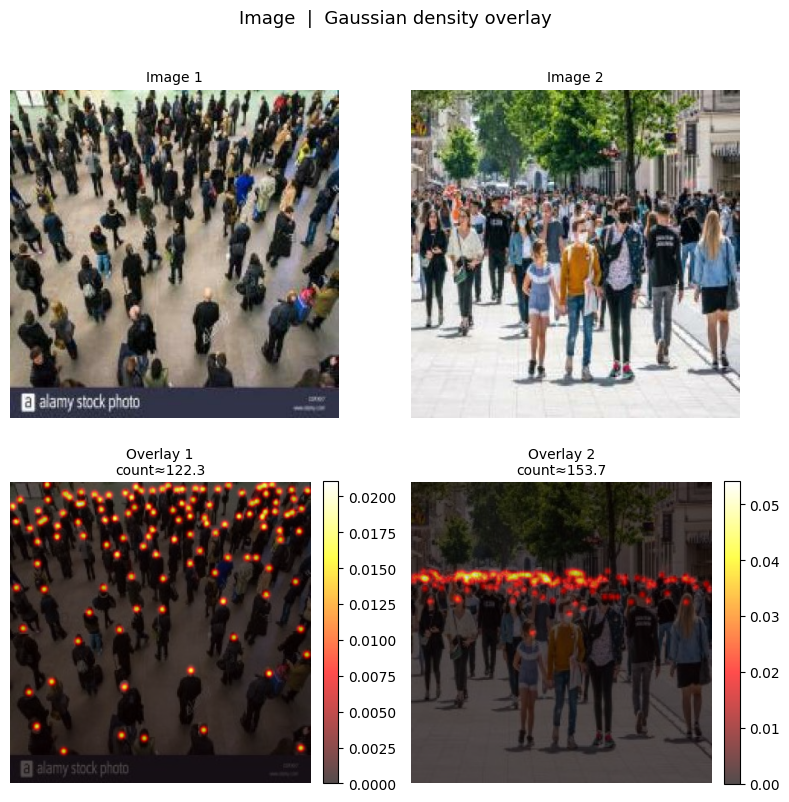

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def visualize_overlay(dataset, num_samples=4, alpha=0.5):
    fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 8))

    for images, labels in dataset.take(1):
        for i in range(min(num_samples, images.shape[0])):
            img   = images[i].numpy()
            label = labels[i].numpy()[..., 0]

            axes[0, i].imshow(img)
            axes[0, i].set_title(f"Image {i+1}", fontsize=10)
            axes[0, i].axis("off")

            axes[1, i].imshow(img)
            heatmap = axes[1, i].imshow(
                label,
                cmap="hot",
                alpha=alpha,
                vmin=0,
                vmax=label.max() or 1e-6,  # ← scale to actual peak, not 1.0
            )
            plt.colorbar(heatmap, ax=axes[1, i], fraction=0.046, pad=0.04)
            axes[1, i].set_title(f"Overlay {i+1}\ncount≈{label.sum():.1f}", fontsize=10)
            axes[1, i].axis("off")

    fig.suptitle("Image  |  Gaussian density overlay", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("overlay_preview.png", dpi=150, bbox_inches="tight")
    plt.show()


visualize_overlay(test_ds, num_samples=2, alpha=0.7)

## CNN Model Training
- Load our images
- Preprocess
- Build a CNN to find patterns
- Compile CNN
- Fit To our training data

### Building the CNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Conv2DTranspose,
    MaxPool2D,
    Concatenate,
    BatchNormalization,
    ReLU
)

# U-Net with skip connections
inputs = tf.keras.Input(shape=(400, 400, 3))

# Encoder
e1 = tf.keras.layers.Conv2D(16, 3, activation="relu", padding='same')(inputs)
p1 = tf.keras.layers.MaxPool2D(2)(e1)          # 200x200

e2 = tf.keras.layers.Conv2D(32, 3, activation="relu", padding='same')(p1)
p2 = tf.keras.layers.MaxPool2D(2)(e2)          # 100x100

e3 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding='same')(p2)
p3 = tf.keras.layers.MaxPool2D(2)(e3)          # 50x50

# Bottleneck
b = tf.keras.layers.Conv2D(128, 3, activation="relu", padding='same')(p3)

# Decoder + skip connections
d3 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(b)
d3 = tf.keras.layers.Concatenate()([d3, e3])   # skip from e3

d2 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(d3)
d2 = tf.keras.layers.Concatenate()([d2, e2])   # skip from e2

d1 = tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(d2)
d1 = tf.keras.layers.Concatenate()([d1, e1])   # skip from e1

outputs = tf.keras.layers.Conv2D(1, 1, activation='relu', padding='same')(d1)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 400, 400,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 200, 200,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 200, 200,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 100, 100,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 100, 100,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 50, 50,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 50, 50,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 100, 100,  │     73,792 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 100,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 200, 200,  │     36,896 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 200,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 400, 400,  │      9,232 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 400, 400,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 400, 400,  │         33 │ concatenate_2[0]… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,393 (849.19 KB)

 Trainable params: 217,393 (849.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

def density_loss(
    lambda_ssim=0.2,
    lambda_count=0.05
):
    """
    Composite Density Map Loss

    Total Loss =
      MSE
      + lambda_ssim * SSIM Loss
      + lambda_count * Count Loss
    """

    def loss(y_true, y_pred):

        # -------------------------------------------------
        # 1. Pixel-wise MSE
        # -------------------------------------------------
        mse = tf.reduce_mean(
            tf.square(y_true - y_pred)
        )

        # -------------------------------------------------
        # 2. Structural Similarity Loss
        # -------------------------------------------------
        ssim = tf.image.ssim(
            tf.clip_by_value(y_true, 0., 1.),
            tf.clip_by_value(y_pred, 0., 1.),
            max_val=1.0
        )
        ssim_loss = 1.0 - tf.reduce_mean(ssim)

        # -------------------------------------------------
        # 3. Count Loss
        # Sum of density map = crowd count
        # -------------------------------------------------
        pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
        true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])

        count_loss = tf.reduce_mean(
            tf.abs(pred_count - true_count) /
            (true_count + 1.0)
        )

        # -------------------------------------------------
        # Total Loss
        # -------------------------------------------------
        total_loss = (
            mse
            + lambda_ssim * ssim_loss
            + lambda_count * count_loss
        )

        return total_loss

    return loss


In [ ]:
import tensorflow as tf

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def pixel_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def pixel_rmse(y_true, y_pred):
    return tf.sqrt(
        tf.reduce_mean(tf.square(y_true - y_pred))
    )


def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )


def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(
        tf.image.psnr(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

def count_metric(y_true, y_pred):
    pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
    true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])
    return tf.reduce_mean(
        tf.abs((pred_count - true_count)/(true_count+1))
    )




In [ ]:
# custom_objects = {
#     'pixel_mae': pixel_mae,
#     'pixel_rmse': pixel_rmse,
#     'ssim_metric': ssim_metric,
#     'psnr_metric': psnr_metric,
#     'loss': density_loss
# }

# model = tf.keras.models.load_model(
#     '/content/updated_loss_model.keras',
#     custom_objects=custom_objects
# )
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=9e-4,
        clipnorm=1.0
    ),
    loss=[
        density_loss(), # For 'main'
    ],
    metrics=[
        pixel_mae,
        pixel_rmse,
        ssim_metric,
        psnr_metric,
        count_metric
    ]
)

In [ ]:
# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "updated_loss_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)
# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=130,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/130
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - count_metric: 0.8893 - loss: 0.0560 - pixel_mae: 0.0014 - pixel_rmse: 0.0049 - psnr_metric: 48.6893 - ssim_metric: 0.9426
Epoch 1: val_loss improved from None to 0.04449, saving model to updated_loss_model.keras

Epoch 1: finished saving model to updated_loss_model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 85s 405ms/step - count_metric: 0.8186 - loss: 0.0521 - pixel_mae: 0.0014 - pixel_rmse: 0.0050 - psnr_metric: 48.3248 - ssim_metric: 0.9444 - val_count_metric: 0.6437 - val_loss: 0.0445 - val_pixel_mae: 0.0015 - val_pixel_rmse: 0.0055 - val_psnr_metric: 46.5724 - val_ssim_metric: 0.9384 - learning_rate: 9.0000e-04
Epoch 2/130
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - count_metric: 0.6689 - loss: 0.0457 - pixel_mae: 0.0015 - pixel_rmse: 0.0055 - psnr_metric: 46.7343 - ssim_metric: 0.9390
Epoch 2: val_loss improved from 0.04449 to 0.04318, saving model to updated_loss_model.keras

Epoch 2: finished saving model to updated_loss_model.k

ValueError: num must be an integer with 1 <= num <= 6, not 7

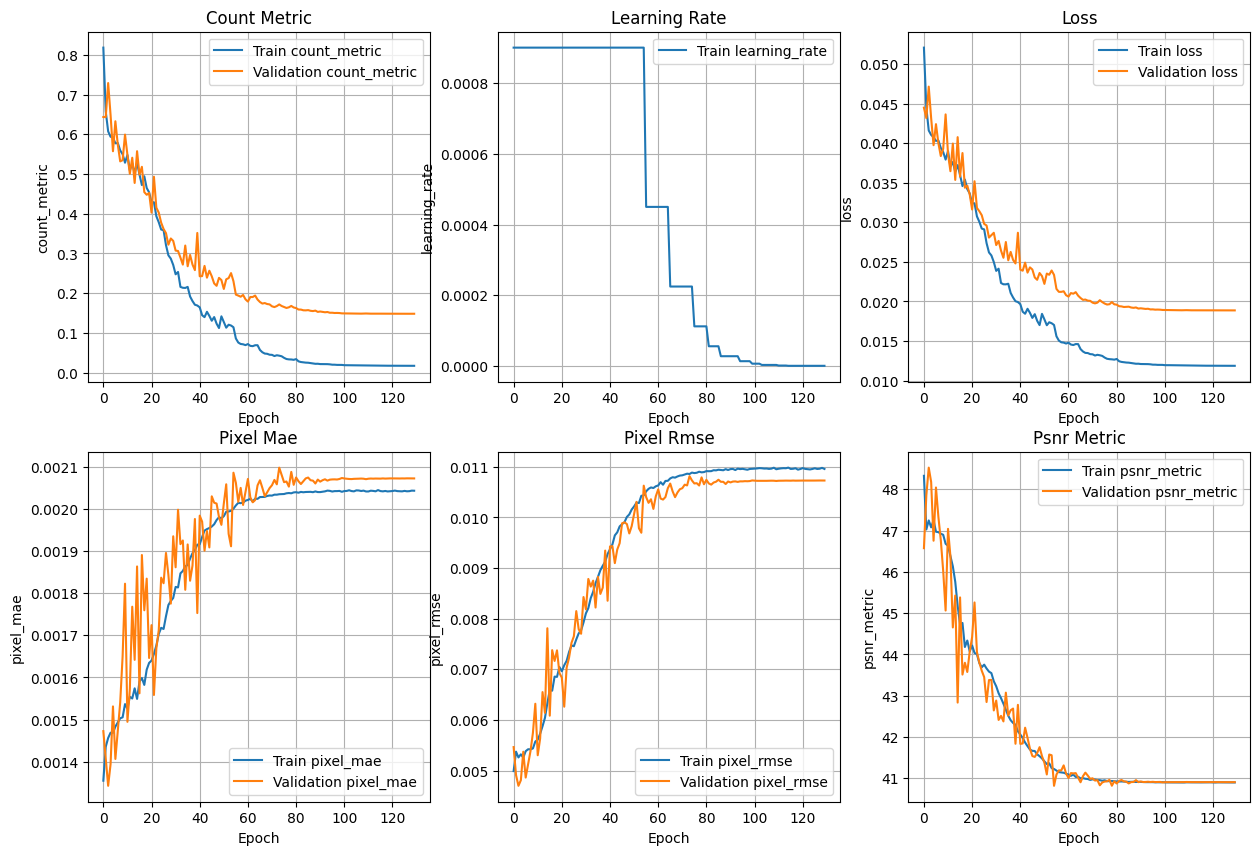

In [ ]:
import matplotlib.pyplot as plt

# Get all metric names from history, excluding validation metrics for iteration
metric_names = [key.replace('val_', '') for key in history.history.keys() if not key.startswith('val_')]
metric_names = sorted(list(set(metric_names))) # Remove duplicates and sort

# Filter out 'lr' if present, as it's not a performance metric to plot like others
if 'lr' in metric_names:
    metric_names.remove('lr')

# Plot each metric
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metric_names):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    plt.plot(history.history[metric], label=f'Train {metric}')
    if f'val_{metric}' in history.history:
        plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    plt.title(metric.replace('_', ' ').title()) # Capitalize and replace underscores for better titles
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def test_image(model, image_path=r'/content/crowd-counting-dataset-1/test/images/img_1002_jpg.rf.3b81c3ad5100760bced785e5e5eaa82a.jpg', alpha=0.6, threshold=0.5):
    from scipy.ndimage import gaussian_filter

    # ── 1. Derive label path ─────────────────────────────────────────────────
    label_path = image_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    # ── 2. Load & preprocess image ───────────────────────────────────────────
    img_tensor = tf.io.read_file(image_path)
    img_tensor = tf.image.decode_jpeg(img_tensor, channels=3)
    img_tensor = tf.image.resize(img_tensor, IMAGE_SIZE)
    img_tensor = tf.cast(img_tensor, tf.float32) / 255.0   # (H, W, 3)
    img_np     = img_tensor.numpy()

    # ── 3. Build ground-truth density map ───────────────────────────────────
    matrix = np.zeros(IMAGE_SIZE, dtype=np.float32)
    if os.path.getsize(label_path) > 0:
        label  = pd.read_csv(label_path, sep=' ', header=None)
        points = (label[[1, 2]].values * IMAGE_SIZE[0]).astype(int)
        points = np.clip(points, 0, IMAGE_SIZE[0] - 1)
        matrix[points[:, 1], points[:, 0]] = 1.0
        matrix = gaussian_filter(matrix, sigma=3)
    actual_map   = matrix                        # (H, W)
    actual_count = actual_map.sum()

    # ── 4. Predict ───────────────────────────────────────────────────────────
    pred_map = model.predict(img_tensor[np.newaxis, ...])[0, ..., 0]   # (H, W)
    # pred_map[pred_map < threshold] = 0
    pred_count = pred_map.sum()

    print("GT count :", actual_count)
    print("GT max :", actual_map.max())
    print("GT mean:", actual_map.mean())
    print("Pred count:", pred_map.sum())
    print("Pred max :", pred_map.max())
    print("Pred mean:", pred_map.mean())

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    titles = [
        f"Predicted  count ≈ {pred_count:.1f}",
        f"Actual  count ≈ {actual_count:.1f}",
    ]
    maps = [pred_map, actual_map]

    for ax, density, title in zip(axes, maps, titles):
        ax.imshow(img_np)
        heatmap = ax.imshow(
            density,
            cmap="hot",
            alpha=alpha,
            vmin=0,
            vmax=density.max() or 1e-6,
        )
        plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    fig.suptitle(os.path.basename(image_path), fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig("test_image_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
GT count : 123.00001
GT max : 0.021038525
GT mean: 0.00076875003
Pred count: 122.14306
Pred max : 0.44418406
Pred mean: 0.0007633941


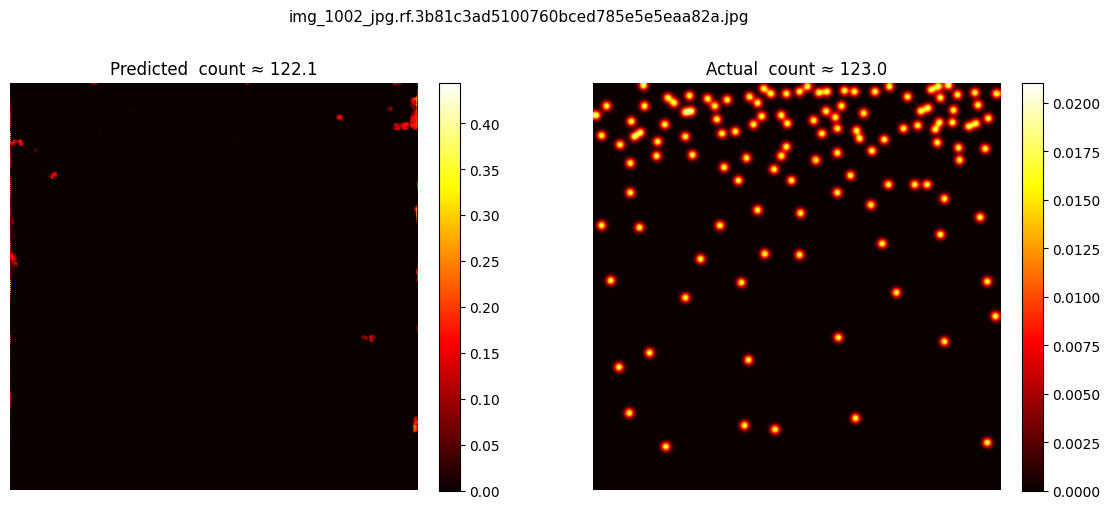

In [ ]:
test_image(model, alpha=1, threshold=0, image_path='')